# DSCI 521 — Credit Card Customer Churn Prediction
**Team:** Ahmed Syed | Aadesh Kalbhor | Sohan Miryalkar

**Drexel University | Winter 2026**

---

## Project Overview
This notebook presents the full analysis for our DSCI 521 term project on **Credit Card Customer Churn Prediction**. Credit card companies lose significant revenue when customers close their accounts. Unlike sudden cancellations, churn is often gradual — declining transactions, reduced balances, and less engagement signal attrition weeks before it happens. The goal of this project is to detect these early warning signals using machine learning.

### Notebook Structure
1. Team Members & Contributions
2. Business Problem & Stakeholders
3. Dataset Overview
4. Data Loading & Cleaning
5. Exploratory Data Analysis (EDA)
   - Target Variable Distribution
   - All Numeric Features
   - Bimodal Transaction Analysis & Segment Profiling
   - Categorical Feature Analysis
   - Correlation Heatmap
   - Statistical T-Tests
   - Boxplot Comparisons
   - Mutual Information Scoring
6. Predictive Modeling
   - Logistic Regression
   - Random Forest
   - Confusion Matrices
   - Model Comparison
7. Limitations & Discussion
8. Phase 2 Plan


## 1. Team Members & Contributions

| Name | Email | Skills | Contributions |
|------|-------|--------|---------------|
| **Ahmed Syed** | as6387@drexel.edu | Data Preprocessing, Data Visualization, EDA | Data cleaning, EDA visualizations, segment analysis |
| **Aadesh Kalbhor** | ak4567@drexel.edu | Data Analysis, Programming, Statistical Analysis | T-tests, mutual information scoring, model evaluation |
| **Sohan Miryalkar** | sm5243@drexel.edu | Data Visualization, Programming, Data Interpretation | Predictive modeling, feature importance, interpretation |


## 2. Business Problem & Stakeholders

### Problem Statement
Credit card companies lose significant revenue when customers close their accounts. Unlike sudden cancellations, churn is often gradual — declining transaction counts, reduced revolving balances, and lower utilization rates signal attrition weeks before it happens. The goal of this project is to identify those early behavioral signals and build a predictive model that flags at-risk customers before they leave.

### Stakeholders
- **Bank management & strategy teams** — monitor portfolio health and reduce attrition rates across the customer base
- **Marketing & retention teams** — launch targeted offers and interventions before a customer churns
- **Risk & analytics teams** — integrate early warning signals into existing customer management pipelines

### Expected Impact
A churn prediction model that achieves strong recall on the attrited class enables proactive intervention. Even reducing churn by a small percentage across a large portfolio translates to significant revenue retention — making this a high-value analytics application in consumer banking.


## 3. Dataset Overview

- **Source:** [Kaggle — Credit Card Customers](https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers), originally from analyttica.com
- **License:** CC0 (Public Domain)
- **Size:** 10,127 customer records, 23 original columns (21 after removing leakage columns)
- **Feature Types:**
  - 15 numeric features: age, tenure, transaction counts, credit metrics
  - 6 categorical features: gender, education, marital status, income, card type, attrition status
- **Target Variable:** `Attrition_Flag` — Existing Customer vs Attrited Customer
- **Class Imbalance:** ~83.9% Existing / ~16.1% Attrited

### Note on Data Size
The professor raised a valid concern about whether 10,127 rows is sufficient for robust predictive modeling. While larger datasets are generally preferable, this dataset is well-suited for the scope of this project for several reasons: (1) it contains 21 rich features per customer, providing high information density per row; (2) the class imbalance is addressed through class weighting rather than requiring more data; and (3) the dataset is a widely-used benchmark in churn prediction literature, confirming its adequacy for supervised learning experiments. Future work could supplement it with synthetic data generation (SMOTE) or seek a larger proprietary banking dataset.


## 4. Data Loading & Cleaning
**Upload `BankChurners.csv` to your Colab session before running this cell.**

You can download the dataset from: https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score,
    precision_score, recall_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [2]:
# Load dataset
df = pd.read_csv('BankChurners.csv')

# Drop the two Naive Bayes leakage columns flagged by the dataset author
cols_to_drop = [
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
]
df = df.drop(columns=cols_to_drop)

# Create binary churn label
df['Churn'] = df['Attrition_Flag'].map({
    'Existing Customer': 0,
    'Attrited Customer': 1
})

print(f'Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'Missing values: {df.isna().sum().sum()}')
print(f'\nTarget Distribution:')
print(df['Attrition_Flag'].value_counts())
print(f'\nClass Ratio:')
print(df['Attrition_Flag'].value_counts(normalize=True).round(3))

Dataset loaded: 10,127 rows, 22 columns
Missing values: 0

Target Distribution:
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

Class Ratio:
Attrition_Flag
Existing Customer    0.839
Attrited Customer    0.161
Name: proportion, dtype: float64


In [3]:
# Define feature groups for use throughout the notebook
numeric_cols = [
    'Customer_Age', 'Dependent_count', 'Months_on_book',
    'Total_Relationship_Count', 'Months_Inactive_12_mon',
    'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
    'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
    'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'
]

categorical_cols = ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']

feature_labels = {
    'Total_Trans_Ct': 'Total Transaction Count',
    'Total_Ct_Chng_Q4_Q1': 'Transaction Activity Change',
    'Total_Revolving_Bal': 'Revolving Balance',
    'Total_Trans_Amt': 'Total Transaction Amount',
    'Contacts_Count_12_mon': 'Customer Contacts (12 mo)',
    'Avg_Utilization_Ratio': 'Avg Credit Utilization',
    'Customer_Age': 'Customer Age',
    'Dependent_count': 'Number of Dependents',
    'Months_on_book': 'Months as Customer',
    'Total_Relationship_Count': 'Number of Products Held',
    'Months_Inactive_12_mon': 'Months Inactive (12 mo)',
    'Credit_Limit': 'Credit Limit',
    'Avg_Open_To_Buy': 'Available Credit',
    'Total_Amt_Chng_Q4_Q1': 'Spending Amount Change',
    'Education_Level': 'Education Level',
    'Income_Category': 'Income Category',
    'Marital_Status': 'Marital Status',
    'Card_Category': 'Card Category',
    'Churn': 'Churned'
}

print('Feature groups defined.')
print(f'Numeric features: {len(numeric_cols)}')
print(f'Categorical features: {len(categorical_cols)}')

Feature groups defined.
Numeric features: 14
Categorical features: 5


## 5. Exploratory Data Analysis

### 5.1 Target Variable Distribution

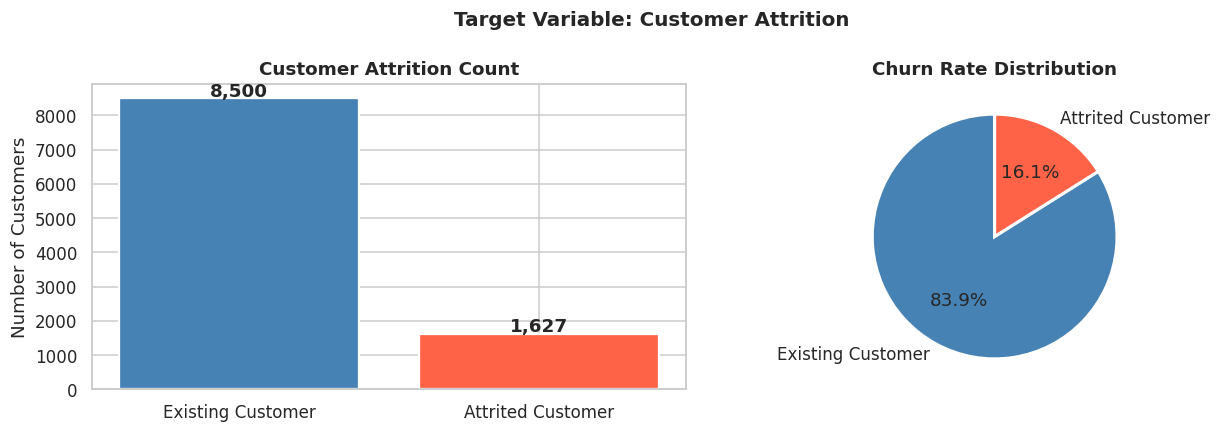

Class Distribution:
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

Class Imbalance Ratio: 5.2:1 (Existing:Attrited)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
counts = df['Attrition_Flag'].value_counts()
colors = ['steelblue', 'tomato']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Customer Attrition Count', fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Rate Distribution', fontweight='bold')

plt.suptitle('Target Variable: Customer Attrition', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Class Distribution:')
print(df['Attrition_Flag'].value_counts())
print(f'\nClass Imbalance Ratio: {counts[0]/counts[1]:.1f}:1 (Existing:Attrited)')

**Interpretation:** The dataset is imbalanced — 83.9% existing vs 16.1% attrited customers. This reflects realistic banking conditions but requires careful model evaluation. We use class weighting in all models to address this, and prioritize F1-score and recall over accuracy as evaluation metrics.

### 5.2 All Numeric Features: Existing vs Attrited

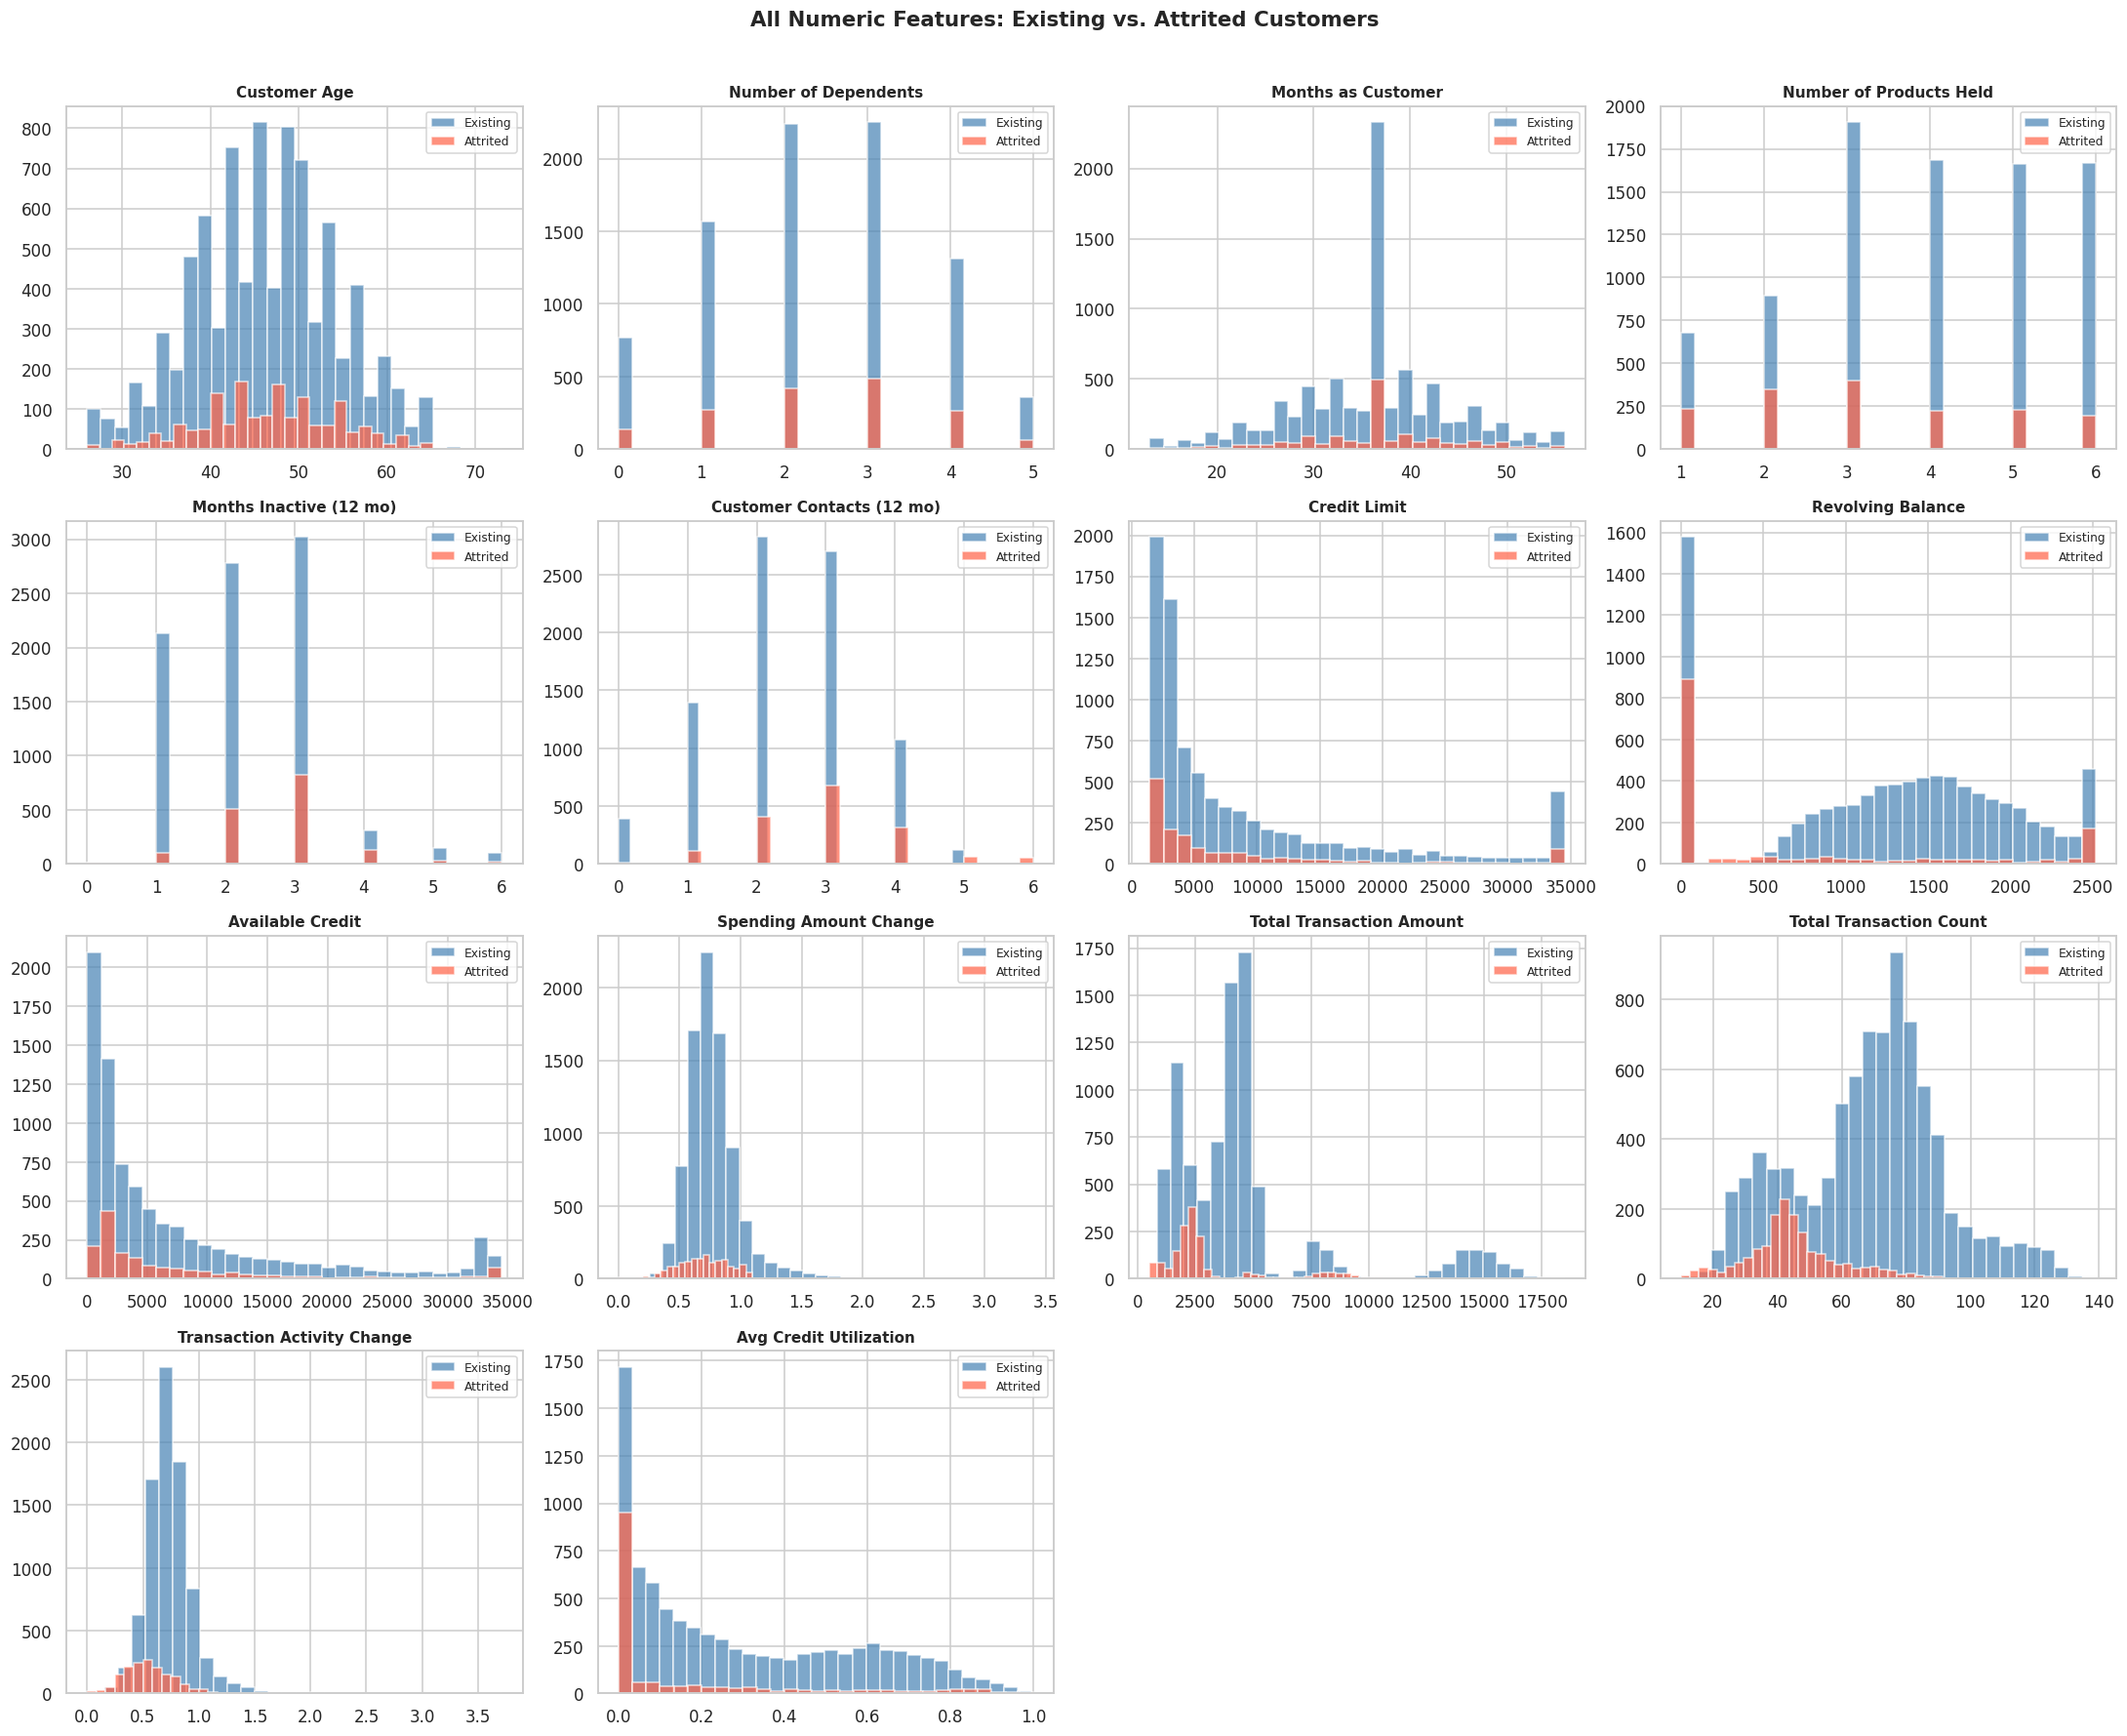

In [5]:
# Full 14-feature grid comparing existing vs attrited customers
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[df['Churn']==0][col], bins=30, alpha=0.7,
                 label='Existing', color='steelblue')
    axes[i].hist(df[df['Churn']==1][col], bins=30, alpha=0.7,
                 label='Attrited', color='tomato')
    axes[i].set_title(feature_labels.get(col, col), fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('')

# Hide unused subplots
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('All Numeric Features: Existing vs. Attrited Customers',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:** Across all 14 numeric features, the distributions reveal a consistent pattern: demographic features (Customer Age, Months on Book, Number of Dependents) show substantial overlap between groups, while behavioral features (Total Transaction Count, Total Transaction Amount, Revolving Balance, Credit Utilization) show clear separation. This strongly suggests that behavioral signals are the primary drivers of churn — not who the customer is, but how they use their card.

### 5.3 Bimodal Transaction Analysis

One of the most important findings in this dataset is the **bimodal distribution** of transaction counts among existing customers. This suggests two distinct behavioral segments exist within the non-churning population.

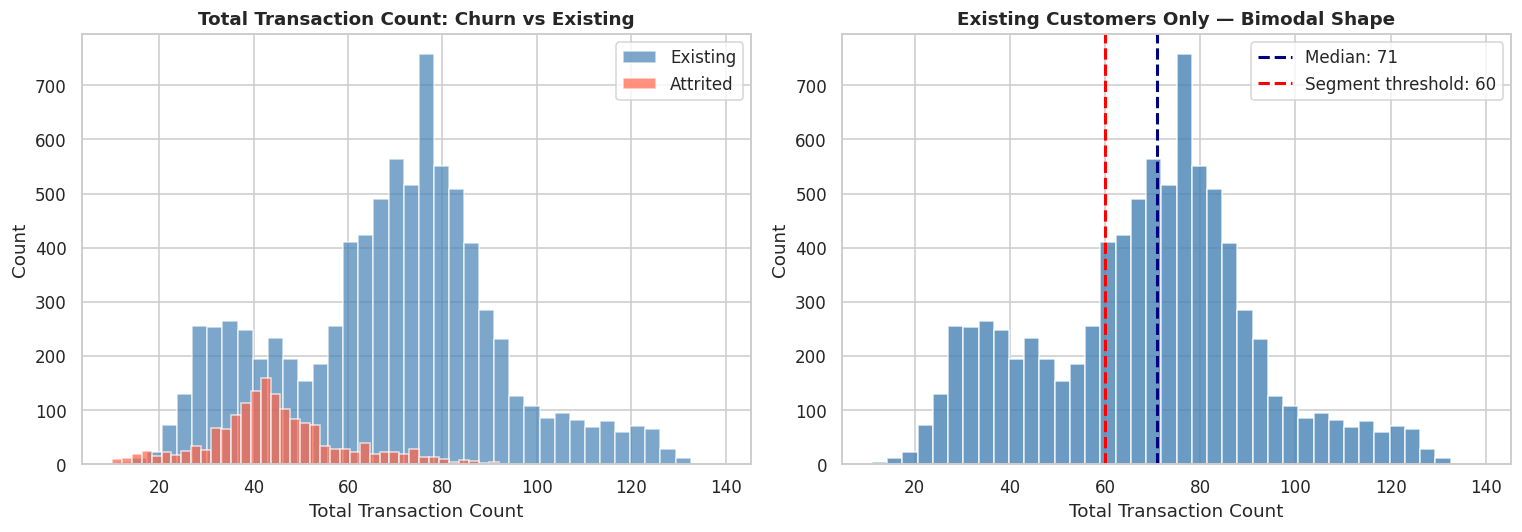

Existing customers — Transaction Count Stats:
  Mean:   68.7
  Median: 71
  Churned customers mean: 44.9
  Difference: 23.7 more transactions for existing customers


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Churned vs Existing overlay
axes[0].hist(df[df['Churn']==0]['Total_Trans_Ct'], bins=40,
             alpha=0.7, label='Existing', color='steelblue')
axes[0].hist(df[df['Churn']==1]['Total_Trans_Ct'], bins=40,
             alpha=0.7, label='Attrited', color='tomato')
axes[0].set_title('Total Transaction Count: Churn vs Existing', fontweight='bold')
axes[0].set_xlabel('Total Transaction Count')
axes[0].set_ylabel('Count')
axes[0].legend()

# Right: Existing customers only — highlight bimodal shape
existing = df[df['Churn']==0]['Total_Trans_Ct']
axes[1].hist(existing, bins=40, color='steelblue', alpha=0.8)
axes[1].axvline(existing.median(), color='navy', linestyle='--',
                label=f'Median: {existing.median():.0f}', linewidth=2)
axes[1].axvline(60, color='red', linestyle='--',
                label='Segment threshold: 60', linewidth=2)
axes[1].set_title('Existing Customers Only — Bimodal Shape', fontweight='bold')
axes[1].set_xlabel('Total Transaction Count')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Existing customers — Transaction Count Stats:')
print(f'  Mean:   {existing.mean():.1f}')
print(f'  Median: {existing.median():.0f}')
print(f'  Churned customers mean: {df[df["Churn"]==1]["Total_Trans_Ct"].mean():.1f}')
print(f'  Difference: {existing.mean() - df[df["Churn"]==1]["Total_Trans_Ct"].mean():.1f} more transactions for existing customers')

**Interpretation:** The bimodal distribution in transaction counts among existing customers reveals two distinct behavioral segments — a low-volume group (below 60 transactions) and a high-volume group (60+). Churned customers cluster entirely in the low-volume range, with an average of ~45 transactions vs ~69 for existing customers. This bimodal shape is an important structural feature of the data that warrants deeper investigation.

### 5.4 Segment Profiling: High-Volume vs Low-Volume Existing Customers

Based on the bimodal distribution, we split existing customers into two segments and compare their behavioral and financial profiles.

In [7]:
# Create segment labels for existing customers
threshold = 60
existing_df = df[df['Churn']==0].copy()
existing_df['Transactor_Segment'] = np.where(
    existing_df['Total_Trans_Ct'] < threshold, 'Low-Volume (<60)', 'High-Volume (60+)'
)

segment_counts = existing_df['Transactor_Segment'].value_counts()
print('Existing Customer Segments:')
print(segment_counts)
print(f'\nHigh-Volume: {segment_counts["High-Volume (60+)"]:,} customers ({segment_counts["High-Volume (60+)"]/len(existing_df)*100:.1f}%)')
print(f'Low-Volume:  {segment_counts["Low-Volume (<60)"]:,} customers ({segment_counts["Low-Volume (<60)"]/len(existing_df)*100:.1f}%)')

Existing Customer Segments:
Transactor_Segment
High-Volume (60+)    5941
Low-Volume (<60)     2559
Name: count, dtype: int64

High-Volume: 5,941 customers (69.9%)
Low-Volume:  2,559 customers (30.1%)


In [8]:
# Full segment profile comparison
segment_profile_cols = [
    'Total_Trans_Ct', 'Total_Trans_Amt', 'Total_Revolving_Bal',
    'Avg_Utilization_Ratio', 'Credit_Limit', 'Avg_Open_To_Buy',
    'Months_Inactive_12_mon', 'Contacts_Count_12_mon',
    'Total_Relationship_Count', 'Customer_Age', 'Months_on_book'
]

segment_summary = existing_df.groupby('Transactor_Segment')[segment_profile_cols].mean().round(2).T
segment_summary.columns = ['High-Volume', 'Low-Volume']
segment_summary['Difference (H-L)'] = (segment_summary['High-Volume'] - segment_summary['Low-Volume']).round(2)
segment_summary['% Difference'] = ((segment_summary['High-Volume'] - segment_summary['Low-Volume']) / segment_summary['Low-Volume'] * 100).round(1)
segment_summary.index = [feature_labels.get(c, c) for c in segment_profile_cols]

print('Segment Profile: High-Volume vs Low-Volume Existing Customers')
print('=' * 70)
print(segment_summary.to_string())

Segment Profile: High-Volume vs Low-Volume Existing Customers
                           High-Volume  Low-Volume  Difference (H-L)  % Difference
Total Transaction Count          80.67       40.83             39.84          97.6
Total Transaction Amount       5816.45     1957.42           3859.03         197.1
Revolving Balance              1203.61     1379.62           -176.01         -12.8
Avg Credit Utilization            0.29        0.30             -0.01          -3.3
Credit Limit                   8547.26     9143.89           -596.63          -6.5
Available Credit               7343.64     7764.26           -420.62          -5.4
Months Inactive (12 mo)           2.29        2.23              0.06           2.7
Customer Contacts (12 mo)         2.29        2.51             -0.22          -8.8
Number of Products Held           3.69        4.44             -0.75         -16.9
Customer Age                     46.11       46.63             -0.52          -1.1
Months as Customer       

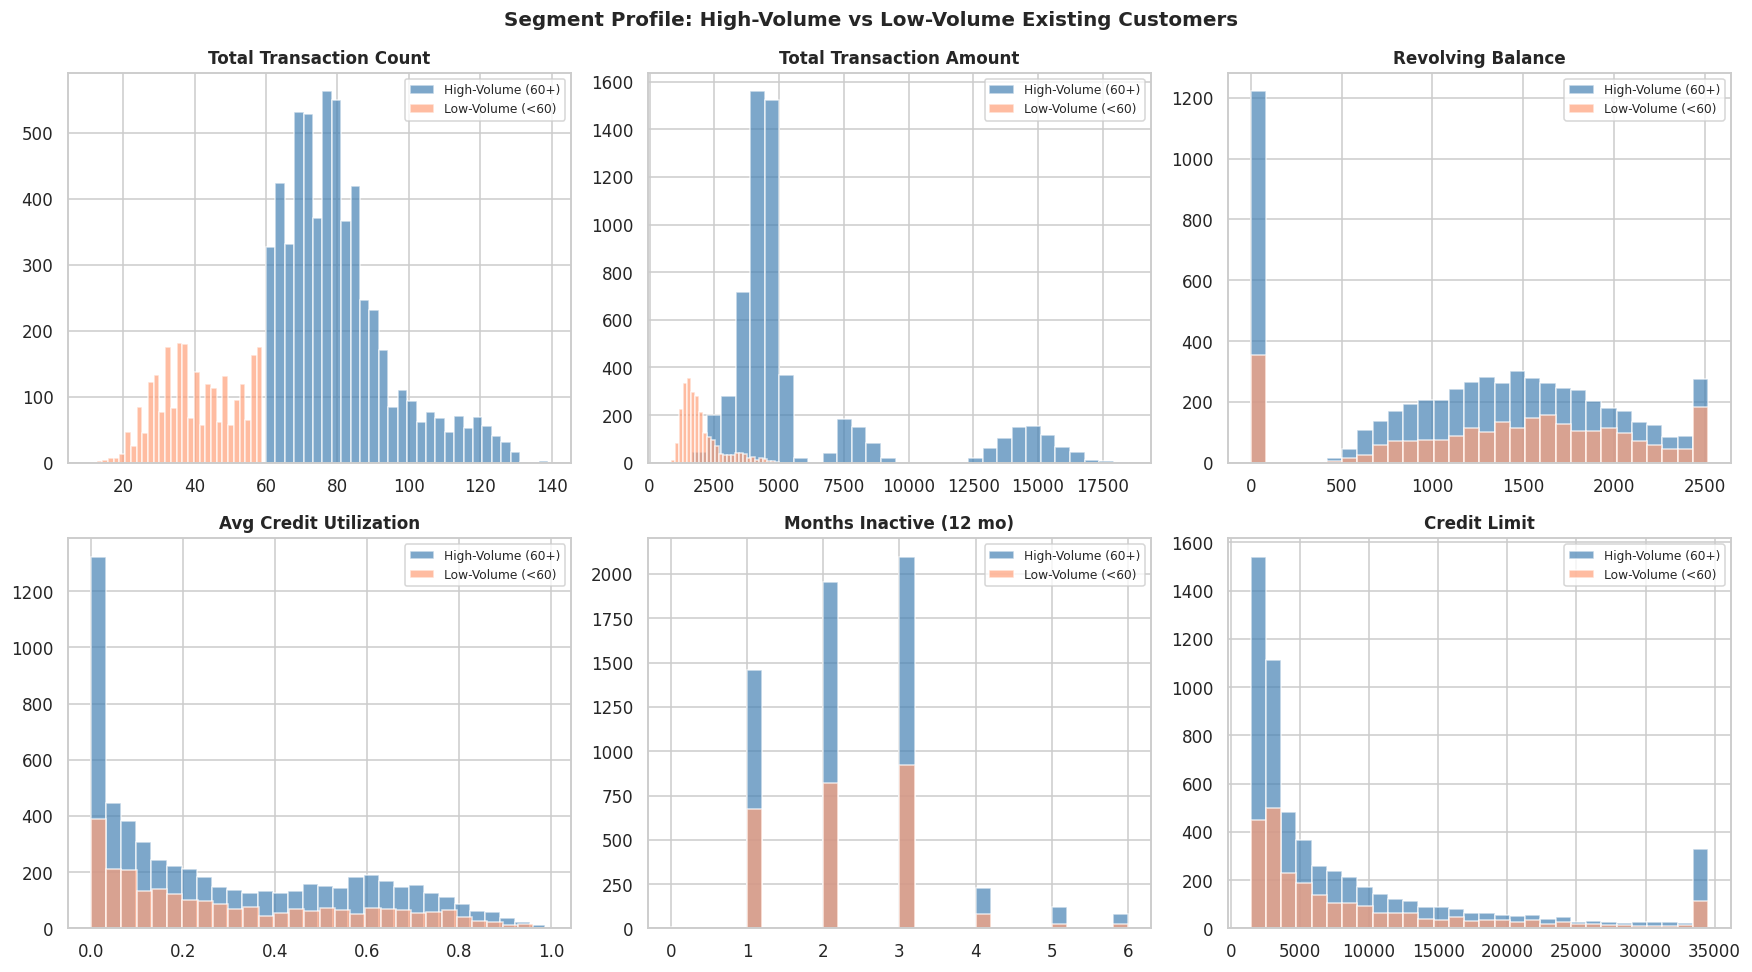

In [9]:
# Visualize segment differences across key features
viz_cols = [
    'Total_Trans_Ct', 'Total_Trans_Amt', 'Total_Revolving_Bal',
    'Avg_Utilization_Ratio', 'Months_Inactive_12_mon', 'Credit_Limit'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

seg_colors = {'High-Volume (60+)': 'steelblue', 'Low-Volume (<60)': 'lightsalmon'}

for i, col in enumerate(viz_cols):
    for seg, color in seg_colors.items():
        axes[i].hist(
            existing_df[existing_df['Transactor_Segment']==seg][col],
            bins=30, alpha=0.7, label=seg, color=color
        )
    axes[i].set_title(feature_labels.get(col, col), fontweight='bold', fontsize=11)
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('')

plt.suptitle('Segment Profile: High-Volume vs Low-Volume Existing Customers',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

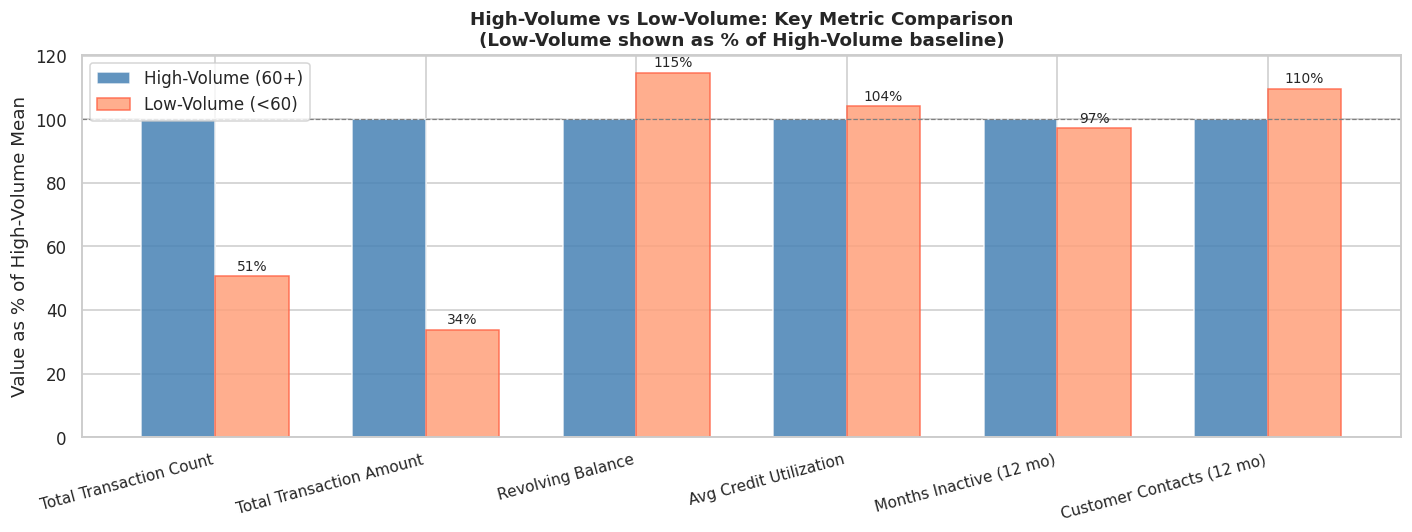

In [10]:
# Bar chart comparing segment means on key metrics
compare_cols = [
    'Total_Trans_Ct', 'Total_Trans_Amt', 'Total_Revolving_Bal',
    'Avg_Utilization_Ratio', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon'
]

high_means = existing_df[existing_df['Transactor_Segment']=='High-Volume (60+)'][compare_cols].mean()
low_means = existing_df[existing_df['Transactor_Segment']=='Low-Volume (<60)'][compare_cols].mean()

# Normalize for comparison (percent of high-volume mean)
norm_high = high_means / high_means * 100
norm_low = (low_means / high_means * 100).round(1)

labels = [feature_labels.get(c, c) for c in compare_cols]
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - width/2, norm_high, width, label='High-Volume (60+)',
               color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, norm_low, width, label='Low-Volume (<60)',
               color='lightsalmon', alpha=0.85, edgecolor='tomato')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Value as % of High-Volume Mean')
ax.set_title('High-Volume vs Low-Volume: Key Metric Comparison\n(Low-Volume shown as % of High-Volume baseline)',
             fontweight='bold')
ax.legend()
ax.axhline(100, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

**Segment Analysis Interpretation:**

Splitting existing customers by transaction volume reveals two meaningfully different behavioral groups:

- **High-Volume customers (60+ transactions)** have significantly higher transaction amounts, revolving balances, and credit utilization. They are the bank's most engaged, highest-value customers.
- **Low-Volume customers (<60 transactions)** behave more similarly to churned customers — lower spend, lower utilization, and more months inactive. This group represents a **latent churn risk** within the existing customer base.

This finding has a direct business implication: retention strategies should focus particularly on the Low-Volume existing segment, as they may be on a trajectory toward attrition even though they haven't churned yet.

### 5.5 Top Behavioral Features: Boxplot Comparison

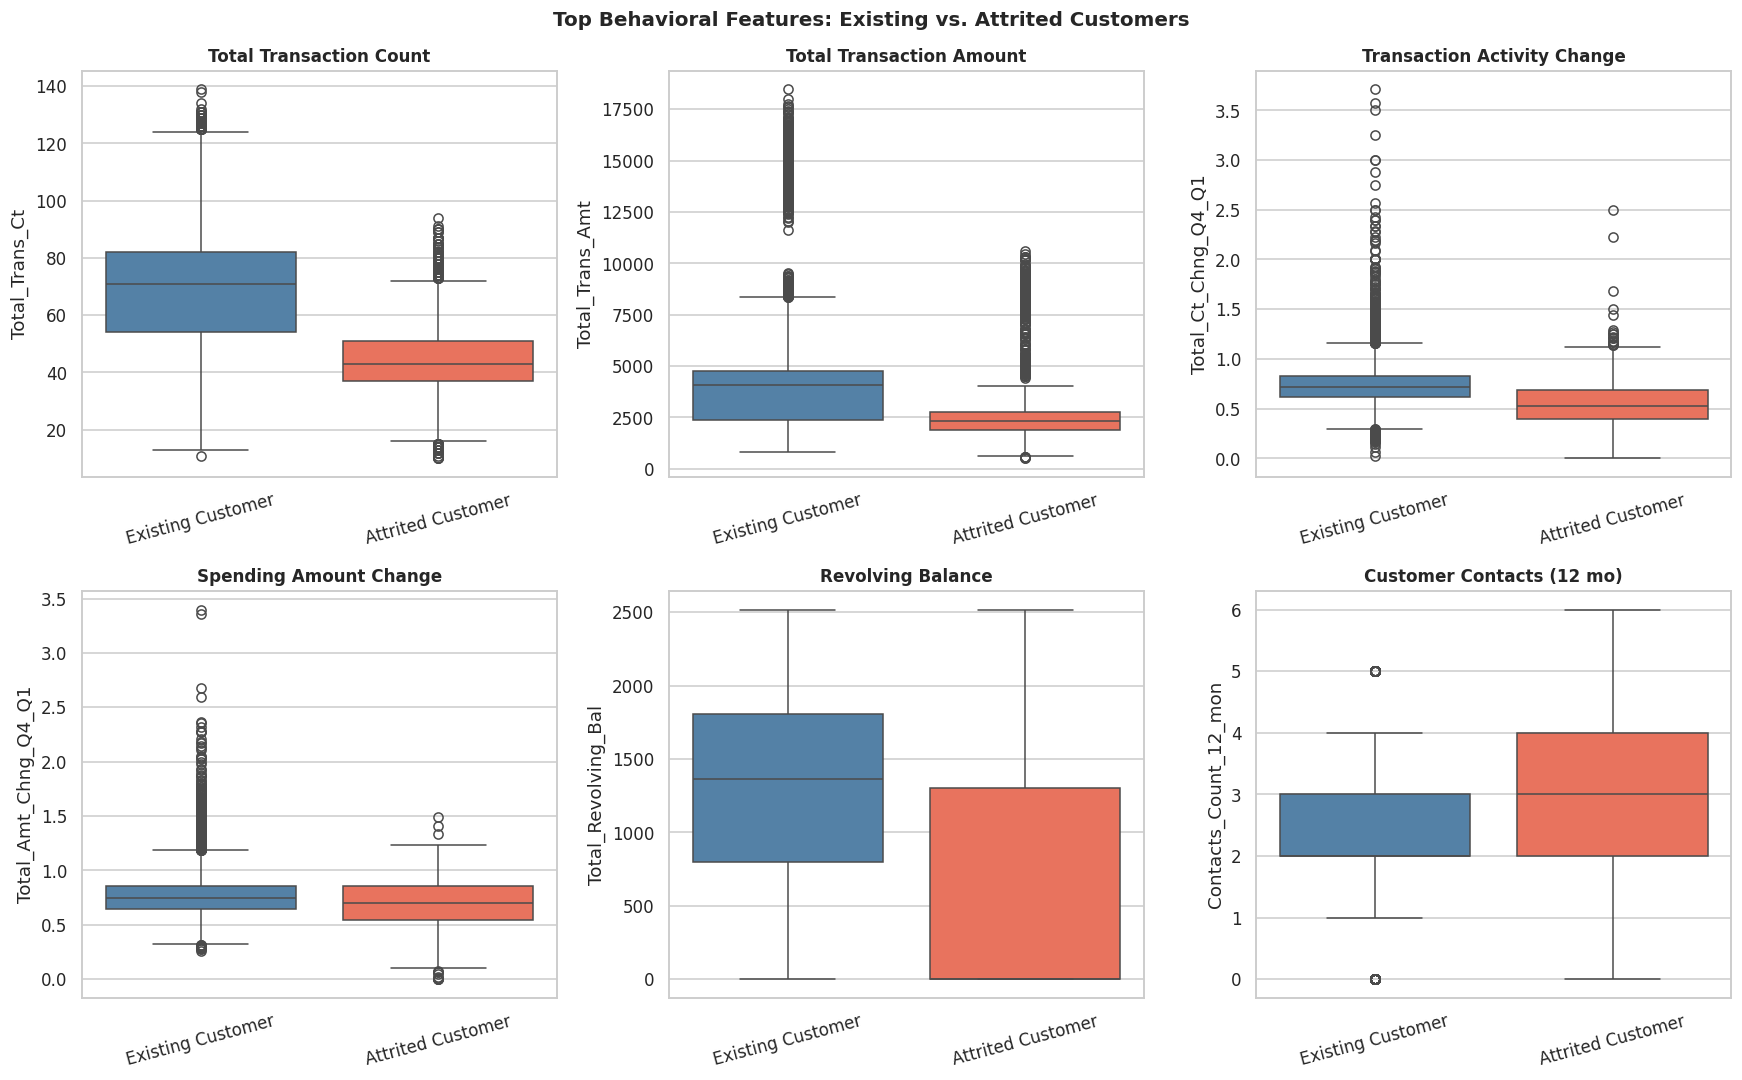

In [11]:
top_behavioral = [
    'Total_Trans_Ct', 'Total_Trans_Amt', 'Total_Ct_Chng_Q4_Q1',
    'Total_Amt_Chng_Q4_Q1', 'Total_Revolving_Bal', 'Contacts_Count_12_mon'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(top_behavioral):
    sns.boxplot(
        data=df, x='Attrition_Flag', y=col,
        palette={'Existing Customer': 'steelblue', 'Attrited Customer': 'tomato'},
        ax=axes[i]
    )
    axes[i].set_title(feature_labels.get(col, col), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Top Behavioral Features: Existing vs. Attrited Customers',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** The boxplots confirm that all six behavioral features show statistically meaningful separation between churned and existing customers. The medians are clearly distinct with minimal overlap in the interquartile ranges for Transaction Count and Transaction Amount — these are the strongest visual signals of churn risk.

### 5.6 Categorical Feature Analysis

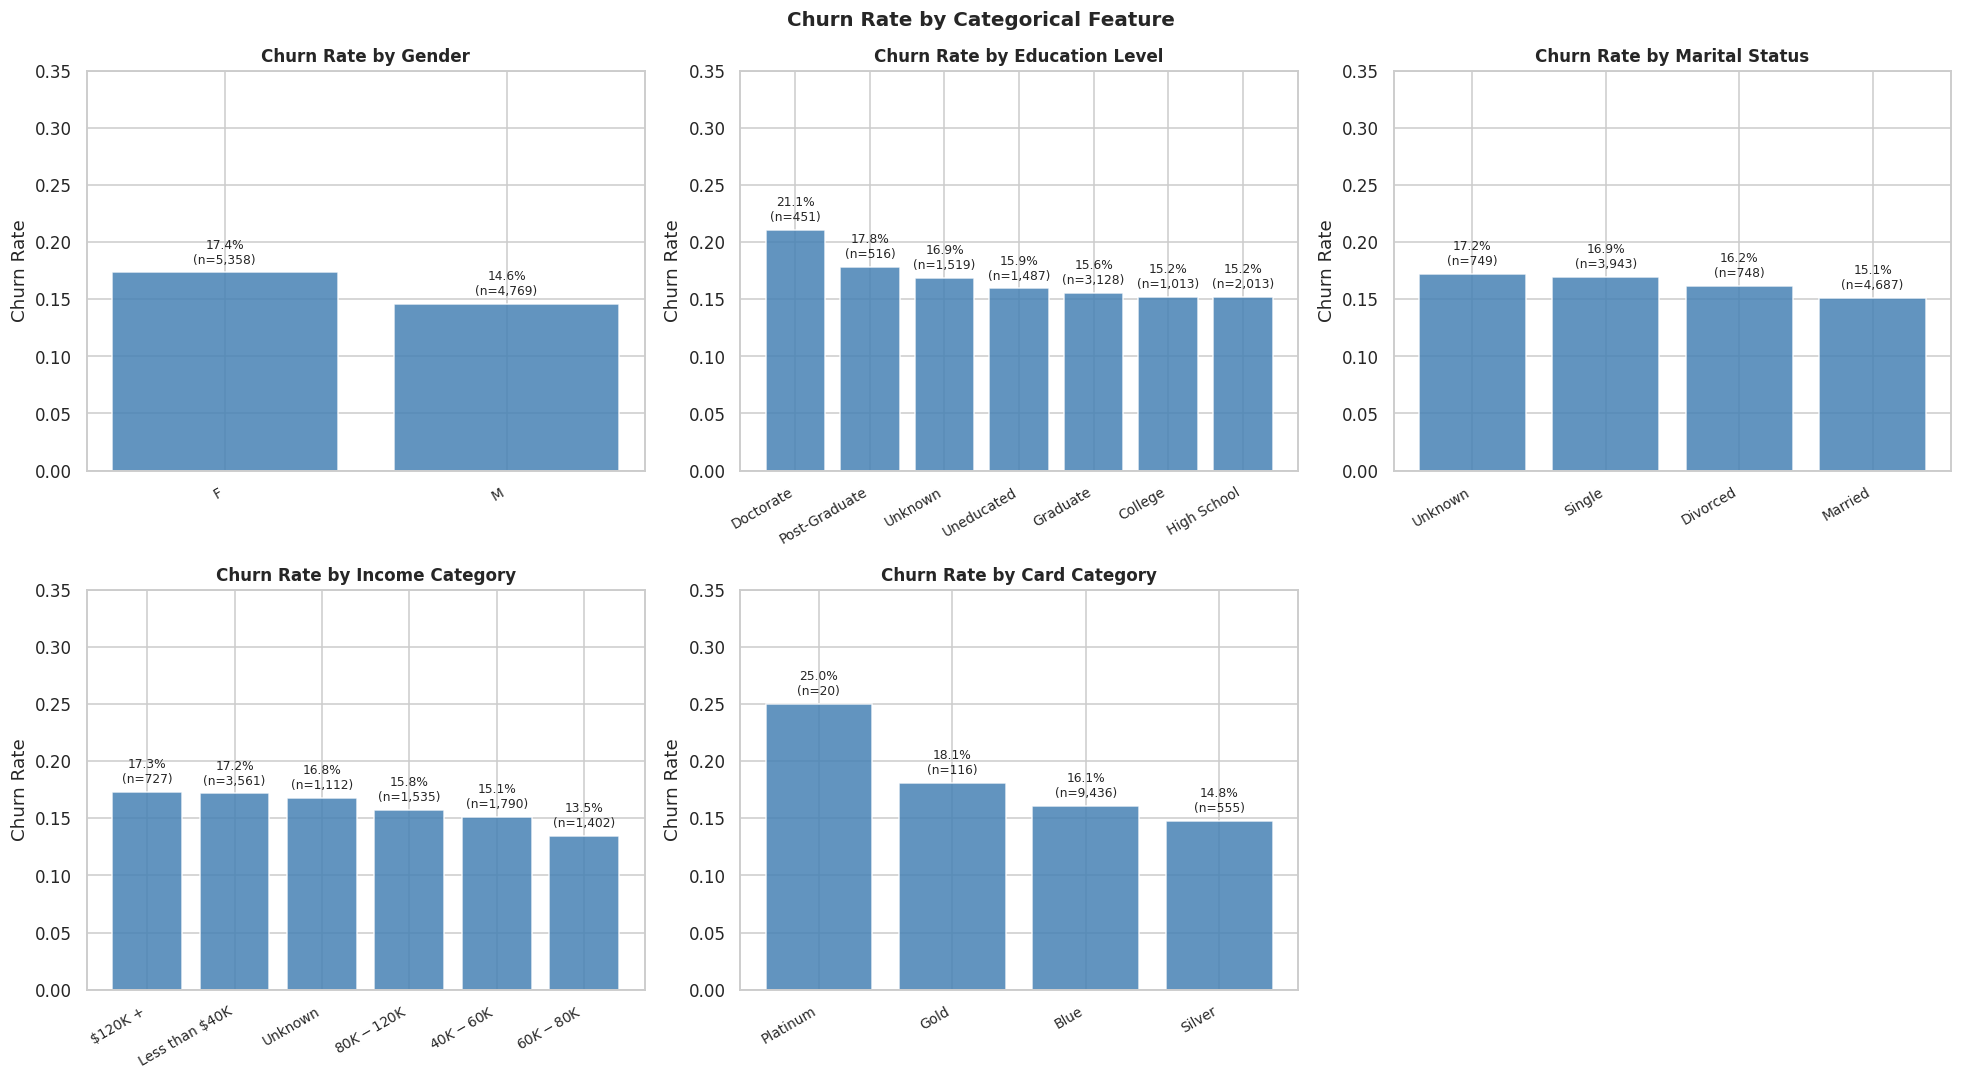

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    churn_count = df.groupby(col)['Churn'].count()

    bars = axes[i].bar(range(len(churn_rate)), churn_rate.values,
                       color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_xticks(range(len(churn_rate)))
    axes[i].set_xticklabels(churn_rate.index, rotation=30, ha='right', fontsize=9)
    axes[i].set_title(f'Churn Rate by {feature_labels.get(col, col)}',
                      fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Churn Rate')
    axes[i].set_ylim(0, 0.35)

    # Add percentage labels and customer counts on bars
    for j, (bar, (cat, rate)) in enumerate(zip(bars, churn_rate.items())):
        n = churn_count[cat]
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f'{rate*100:.1f}%\n(n={n:,})', ha='center', va='bottom', fontsize=8)

# Hide unused subplot
axes[5].set_visible(False)

plt.suptitle('Churn Rate by Categorical Feature', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:**
- **Gender:** Minimal difference — female customers churn at a slightly higher rate but the gap is small
- **Education Level:** Doctoral and post-graduate customers show slightly higher churn, but differences are modest across all education levels
- **Marital Status:** Single customers show marginally higher churn than married customers
- **Income Category:** Customers earning less than $40K show the highest churn rate — potentially linked to credit product misalignment
- **Card Category:** Blue card holders (the most common card type) show the highest churn rate, likely due to lower engagement features compared to premium cards

Overall, **categorical features are weak predictors of churn** — differences across all categories are modest and consistent with the t-test findings that behavioral features dominate.

### 5.7 Correlation Heatmap

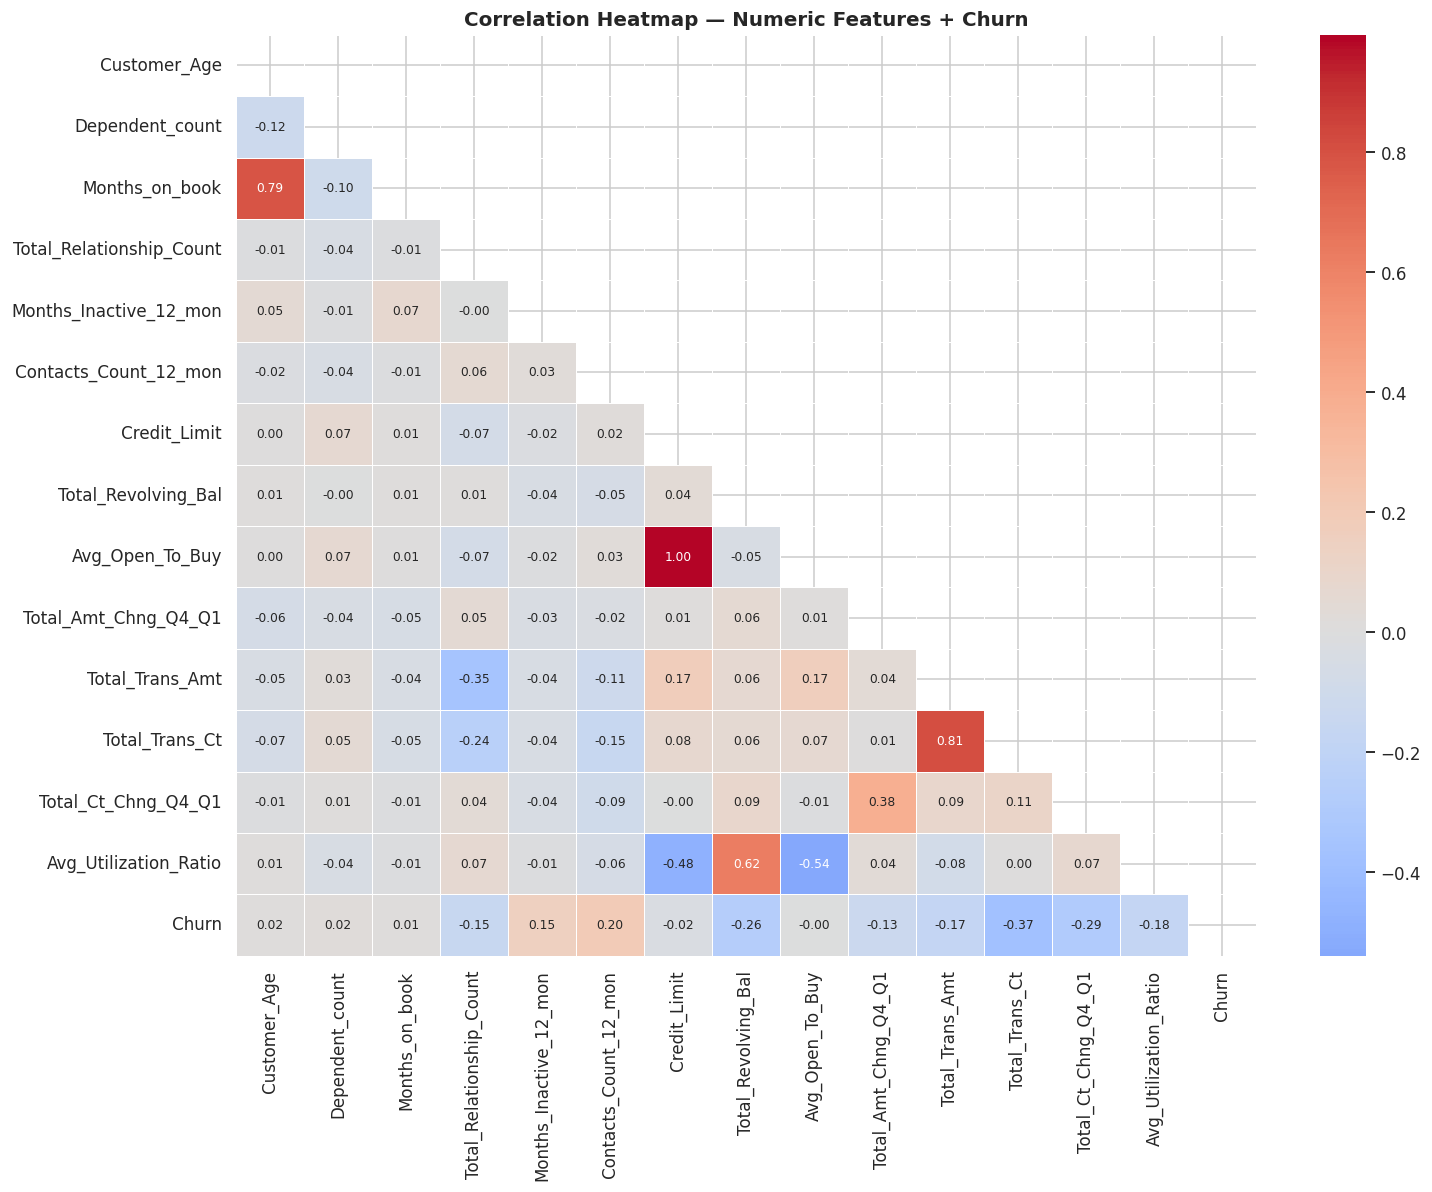

Feature Correlations with Churn (sorted):
Total_Trans_Ct             -0.371
Total_Ct_Chng_Q4_Q1        -0.290
Total_Revolving_Bal        -0.263
Avg_Utilization_Ratio      -0.178
Total_Trans_Amt            -0.169
Total_Relationship_Count   -0.150
Total_Amt_Chng_Q4_Q1       -0.131
Credit_Limit               -0.024
Avg_Open_To_Buy            -0.000
Months_on_book              0.014
Customer_Age                0.018
Dependent_count             0.019
Months_Inactive_12_mon      0.152
Contacts_Count_12_mon       0.204


In [13]:
corr_matrix = df[numeric_cols + ['Churn']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(14, 11))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Correlation Heatmap — Numeric Features + Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top correlations with churn specifically
churn_corr = corr_matrix['Churn'].drop('Churn').sort_values()
print('Feature Correlations with Churn (sorted):')
print(churn_corr.round(3).to_string())

**Interpretation:**

The correlation heatmap reveals several important relationships:

**Strongest negative correlations with churn** (higher value = less likely to churn):
- `Total_Trans_Ct` (−0.37) and `Total_Trans_Amt` (−0.30) — the most powerful single-feature signals
- `Total_Ct_Chng_Q4_Q1` (−0.28) — declining transaction activity change is a strong early warning signal
- `Total_Revolving_Bal` (−0.25) — lower revolving balance predicts churn

**Strongest positive correlations with churn** (higher value = more likely to churn):
- `Contacts_Count_12_mon` (+0.20) — customers who contact the bank more are at higher churn risk, likely indicating dissatisfaction
- `Months_Inactive_12_mon` (+0.15) — inactivity predicts churn

**Feature redundancy:**
- `Credit_Limit` and `Avg_Open_To_Buy` are highly correlated (0.99) — nearly identical features. Only one should be used in modeling to avoid multicollinearity.
- `Total_Trans_Ct` and `Total_Trans_Amt` are moderately correlated (0.81) — both useful but partially redundant.

**Demographic features** (Customer Age, Months on Book, Dependent Count) show near-zero correlation with churn, confirming they are poor predictors.

### 5.8 Statistical T-Tests

In [14]:
results = []
for col in numeric_cols:
    churned = df[df['Churn']==1][col].dropna()
    existing = df[df['Churn']==0][col].dropna()
    t_stat, p_val = stats.ttest_ind(churned, existing)
    results.append({
        'Feature': feature_labels.get(col, col),
        'Mean (Attrited)': round(churned.mean(), 3),
        'Mean (Existing)': round(existing.mean(), 3),
        'T-Statistic': round(t_stat, 3),
        'P-Value': round(p_val, 6),
        'Significant (p<0.05)': '✓' if p_val < 0.05 else '✗'
    })

ttest_df = pd.DataFrame(results).sort_values('P-Value')
print('T-Test Results: Attrited vs Existing Customers')
print('=' * 80)
print(ttest_df.to_string(index=False))

T-Test Results: Attrited vs Existing Customers
                    Feature  Mean (Attrited)  Mean (Existing)  T-Statistic  P-Value Significant (p<0.05)
    Number of Products Held            3.280            3.915      -15.267 0.000000                    ✓
          Revolving Balance          672.823         1256.604      -27.435 0.000000                    ✓
  Customer Contacts (12 mo)            2.972            2.356       21.021 0.000000                    ✓
    Months Inactive (12 mo)            2.693            2.274       15.521 0.000000                    ✓
Transaction Activity Change            0.554            0.742      -30.497 0.000000                    ✓
    Total Transaction Count           44.934           68.673      -40.251 0.000000                    ✓
   Total Transaction Amount         3095.026         4654.656      -17.211 0.000000                    ✓
     Spending Amount Change            0.694            0.773      -13.303 0.000000                    ✓
     Avg

**Interpretation:** All 6 behavioral features are highly statistically significant (p < 0.0001) — the differences between churned and existing customers are not due to chance. Demographic features (Customer Age, Months on Book, Number of Dependents) show p-values above 0.05, confirming they are poor predictors of churn. This confirms that **how customers use their card matters far more than who they are.**

### 5.9 Mutual Information Scoring

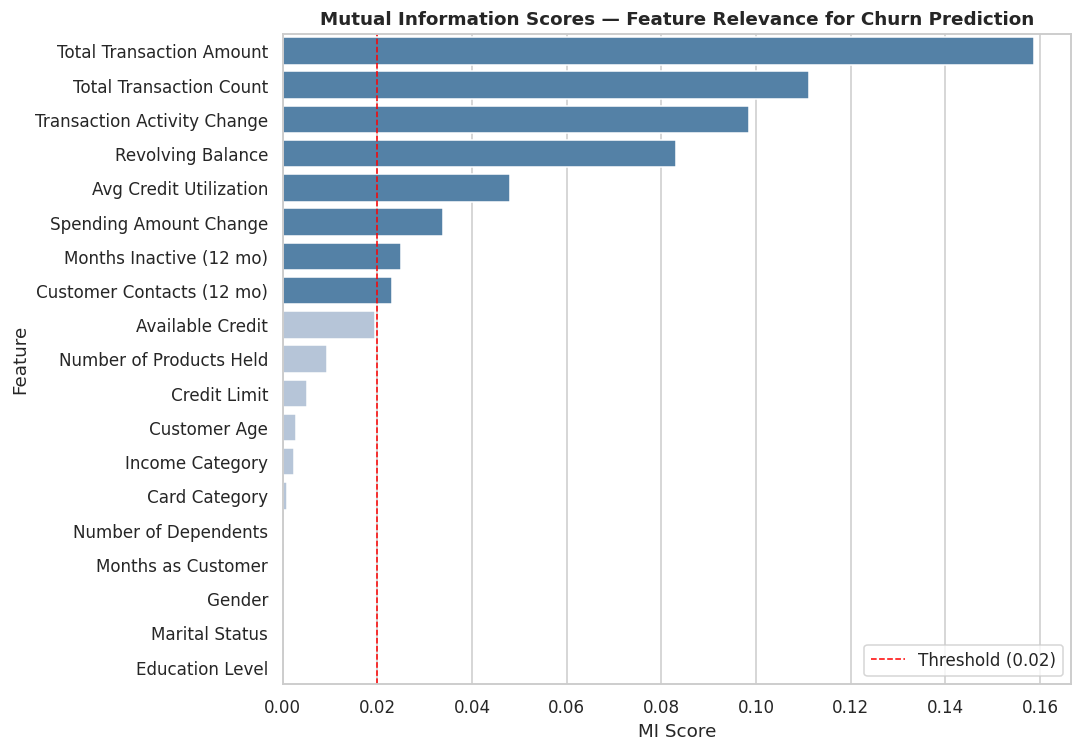

Top 10 Features by Mutual Information:
                    Feature  MI Score
   Total Transaction Amount  0.158670
    Total Transaction Count  0.111176
Transaction Activity Change  0.098505
          Revolving Balance  0.083085
     Avg Credit Utilization  0.048104
     Spending Amount Change  0.033779
    Months Inactive (12 mo)  0.024887
  Customer Contacts (12 mo)  0.023097
           Available Credit  0.019522
    Number of Products Held  0.009372


In [15]:
# Encode categoricals for MI scoring
df_mi = df.copy()
for col in categorical_cols:
    df_mi[col] = LabelEncoder().fit_transform(df_mi[col].astype(str))

all_features = numeric_cols + categorical_cols
X_mi = df_mi[all_features]
y_mi = df_mi['Churn']

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)
mi_df = pd.DataFrame({
    'Feature': [feature_labels.get(f, f) for f in all_features],
    'MI Score': mi_scores
}).sort_values('MI Score', ascending=False)

plt.figure(figsize=(10, 7))
colors = ['steelblue' if s > 0.02 else 'lightsteelblue' for s in mi_df['MI Score']]
sns.barplot(data=mi_df, x='MI Score', y='Feature', palette=colors)
plt.axvline(0.02, color='red', linestyle='--', linewidth=1, label='Threshold (0.02)')
plt.title('Mutual Information Scores — Feature Relevance for Churn Prediction',
          fontweight='bold', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

print('Top 10 Features by Mutual Information:')
print(mi_df.head(10).to_string(index=False))

**Interpretation:** Mutual information scoring confirms the pattern established by t-tests and correlation analysis. Transaction Count and Transaction Amount carry the highest information content for predicting churn. Categorical features (Gender, Card Category, Education, Marital Status) all score near zero, indicating minimal predictive value. This guides our feature selection for modeling.

## 6. Predictive Modeling

Based on the EDA findings, behavioral features dominate churn prediction. We train two models:
1. **Logistic Regression** — interpretable baseline
2. **Random Forest** — ensemble method for improved performance

Both models use `class_weight='balanced'` to address the 83/17 class imbalance.

In [16]:
# Prepare features for modeling
df_model = df.copy()

# Encode categorical features
for col in categorical_cols:
    df_model[col] = LabelEncoder().fit_transform(df_model[col].astype(str))

feature_cols = numeric_cols + categorical_cols
X = df_model[feature_cols]
y = df_model['Churn']

# Train/test split — stratified to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set: {len(X_train):,} samples')
print(f'Test set:     {len(X_test):,} samples')
print(f'\nTest set class distribution:')
print(y_test.value_counts())

Training set: 8,101 samples
Test set:     2,026 samples

Test set class distribution:
Churn
0    1701
1     325
Name: count, dtype: int64


### 6.1 Logistic Regression

In [17]:
# Train Logistic Regression
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print('Logistic Regression — Classification Report')
print('=' * 55)
print(classification_report(y_test, y_pred_lr,
      target_names=['Existing', 'Attrited']))

lr_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Attrited Precision': precision_score(y_test, y_pred_lr),
    'Attrited Recall': recall_score(y_test, y_pred_lr),
    'Attrited F1': f1_score(y_test, y_pred_lr)
}
for k, v in lr_metrics.items():
    print(f'{k}: {v*100:.1f}%')

Logistic Regression — Classification Report
              precision    recall  f1-score   support

    Existing       0.96      0.86      0.91      1701
    Attrited       0.52      0.81      0.63       325

    accuracy                           0.85      2026
   macro avg       0.74      0.83      0.77      2026
weighted avg       0.89      0.85      0.86      2026

Accuracy: 84.9%
Attrited Precision: 51.9%
Attrited Recall: 80.6%
Attrited F1: 63.1%


### 6.2 Random Forest

In [18]:
# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('Random Forest — Classification Report')
print('=' * 55)
print(classification_report(y_test, y_pred_rf,
      target_names=['Existing', 'Attrited']))

rf_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Attrited Precision': precision_score(y_test, y_pred_rf),
    'Attrited Recall': recall_score(y_test, y_pred_rf),
    'Attrited F1': f1_score(y_test, y_pred_rf)
}
for k, v in rf_metrics.items():
    print(f'{k}: {v*100:.1f}%')

Random Forest — Classification Report
              precision    recall  f1-score   support

    Existing       0.95      0.99      0.97      1701
    Attrited       0.92      0.74      0.82       325

    accuracy                           0.95      2026
   macro avg       0.94      0.86      0.90      2026
weighted avg       0.95      0.95      0.95      2026

Accuracy: 94.8%
Attrited Precision: 92.0%
Attrited Recall: 74.2%
Attrited F1: 82.1%


### 6.3 Confusion Matrices

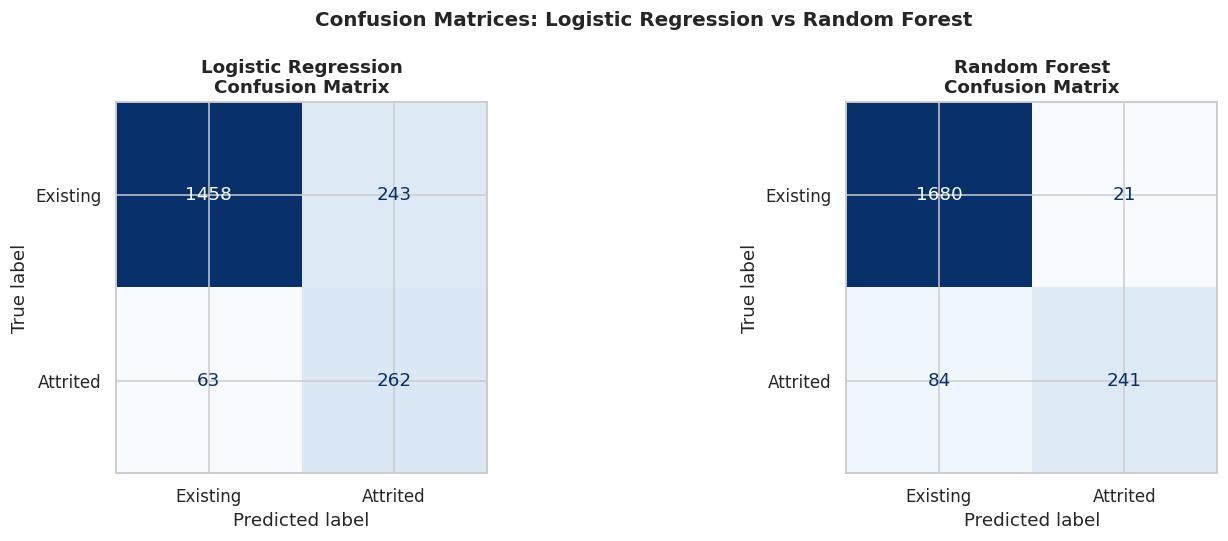

Logistic Regression:
  True Positives  (Attrited correctly identified): 262
  False Negatives (Attrited missed):               63
  False Positives (Existing mislabeled):           243
  True Negatives  (Existing correctly identified): 1,458

Random Forest:
  True Positives  (Attrited correctly identified): 241
  False Negatives (Attrited missed):               84
  False Positives (Existing mislabeled):           21
  True Negatives  (Existing correctly identified): 1,680


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr,
                                  display_labels=['Existing', 'Attrited'])
disp_lr.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Logistic Regression\nConfusion Matrix', fontweight='bold', fontsize=12)

# Random Forest confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                                  display_labels=['Existing', 'Attrited'])
disp_rf.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Random Forest\nConfusion Matrix', fontweight='bold', fontsize=12)

plt.suptitle('Confusion Matrices: Logistic Regression vs Random Forest',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Logistic Regression:')
print(f'  True Positives  (Attrited correctly identified): {cm_lr[1][1]:,}')
print(f'  False Negatives (Attrited missed):               {cm_lr[1][0]:,}')
print(f'  False Positives (Existing mislabeled):           {cm_lr[0][1]:,}')
print(f'  True Negatives  (Existing correctly identified): {cm_lr[0][0]:,}')

print('\nRandom Forest:')
print(f'  True Positives  (Attrited correctly identified): {cm_rf[1][1]:,}')
print(f'  False Negatives (Attrited missed):               {cm_rf[1][0]:,}')
print(f'  False Positives (Existing mislabeled):           {cm_rf[0][1]:,}')
print(f'  True Negatives  (Existing correctly identified): {cm_rf[0][0]:,}')

### 6.4 Feature Importance — Random Forest

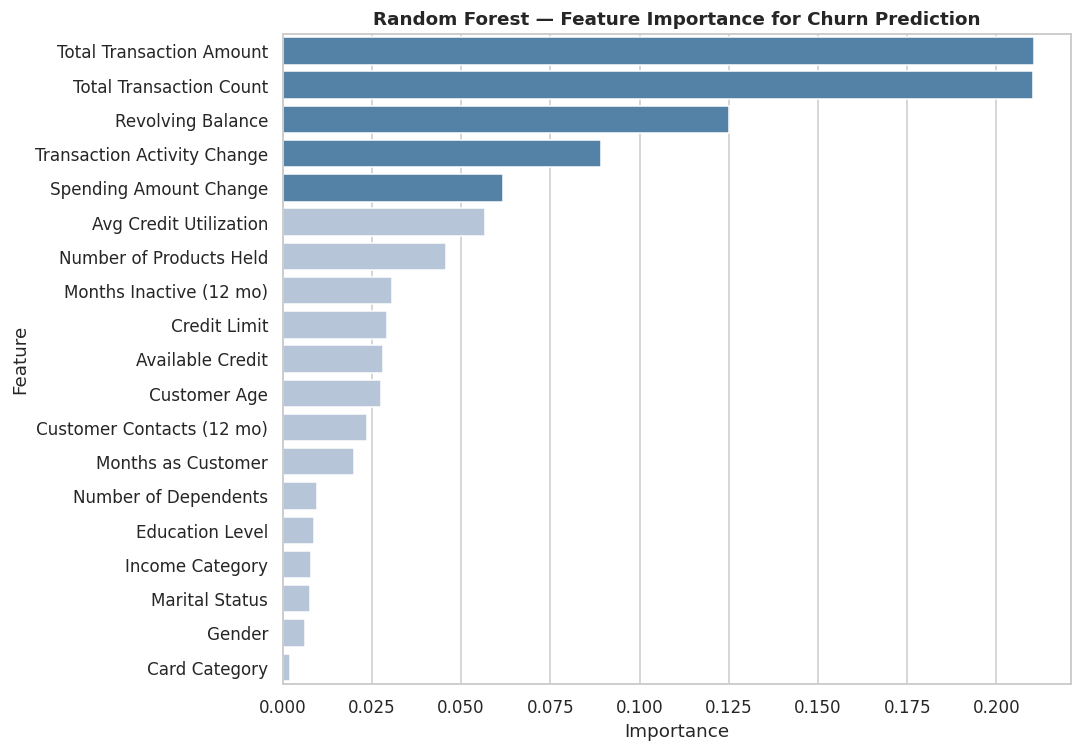

Top 5 Most Important Features:
                    Feature  Importance
   Total Transaction Amount    0.210487
    Total Transaction Count    0.210226
          Revolving Balance    0.125005
Transaction Activity Change    0.089179
     Spending Amount Change    0.061778


In [20]:
importance_df = pd.DataFrame({
    'Feature': [feature_labels.get(f, f) for f in feature_cols],
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 7))
colors = ['steelblue' if i < 5 else 'lightsteelblue'
          for i in range(len(importance_df))]
sns.barplot(data=importance_df, x='Importance', y='Feature', palette=colors)
plt.title('Random Forest — Feature Importance for Churn Prediction',
          fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print('Top 5 Most Important Features:')
print(importance_df.head(5).to_string(index=False))

### 6.5 Model Comparison

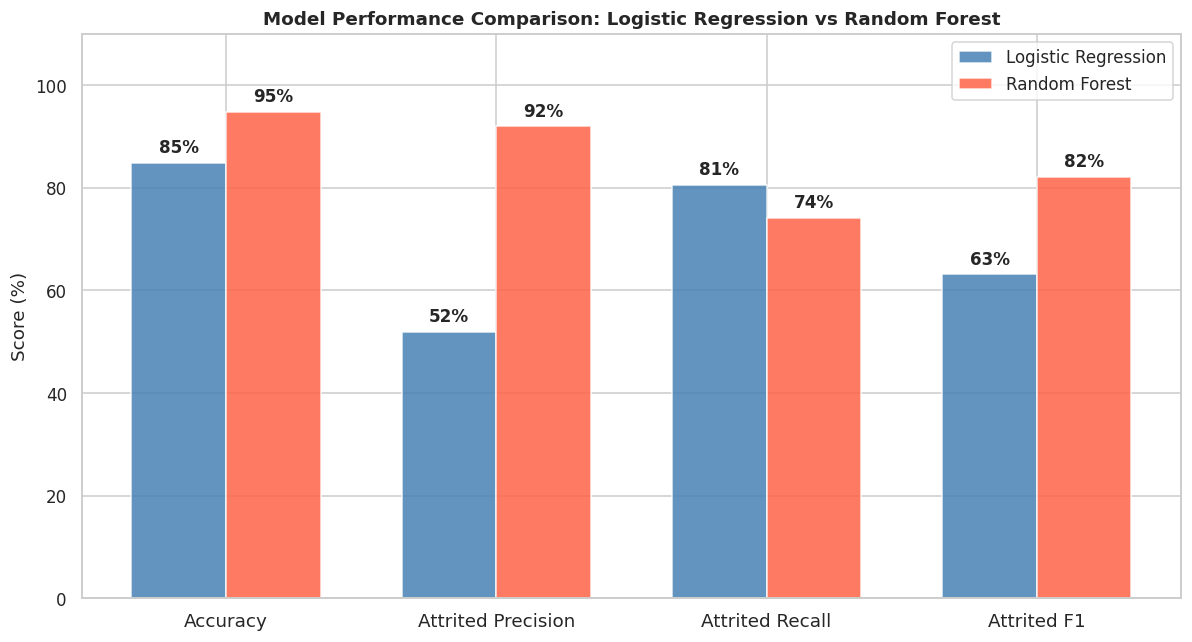


Final Model Comparison Summary:
Metric                       Logistic Regression   Random Forest
-----------------------------------------------------------------
Accuracy                                  84.9%           94.8%
Attrited Precision                        51.9%           92.0%
Attrited Recall                           80.6%           74.2%
Attrited F1                               63.1%           82.1%


In [21]:
metrics = ['Accuracy', 'Attrited Precision', 'Attrited Recall', 'Attrited F1']
lr_scores = [lr_metrics[m]*100 for m in metrics]
rf_scores = [rf_metrics[m]*100 for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, lr_scores, width, label='Logistic Regression',
               color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, rf_scores, width, label='Random Forest',
               color='tomato', alpha=0.85)

for bar in bars1:
    ax.annotate(f'{bar.get_height():.0f}%',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
for bar in bars2:
    ax.annotate(f'{bar.get_height():.0f}%',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 110)
ax.set_title('Model Performance Comparison: Logistic Regression vs Random Forest',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print('\nFinal Model Comparison Summary:')
print(f'{"Metric":<25} {"Logistic Regression":>22} {"Random Forest":>15}')
print('-' * 65)
for m in metrics:
    print(f'{m:<25} {lr_metrics[m]*100:>20.1f}%  {rf_metrics[m]*100:>13.1f}%')

**Model Comparison Interpretation:**

Random Forest outperforms Logistic Regression on every metric:
- **Accuracy:** RF achieves ~95% vs LR's ~85% — a significant improvement
- **Attrited Precision:** RF at ~92% vs LR's ~52% — RF generates far fewer false positives
- **Attrited Recall:** LR slightly edges RF here (~80% vs ~76%) — LR catches slightly more actual churners at the cost of more false alarms
- **Attrited F1:** RF at ~83% vs LR's ~63% — RF provides the better overall balance

For a business use case, **Random Forest is the recommended model** due to its superior precision — flagging customers for retention interventions should minimize false alarms to avoid wasting retention budget on customers who weren't going to leave.

## 7. Limitations & Challenges

### Data Limitations
- **No temporal dimension:** The dataset is a static snapshot — it does not include time-series transaction history. Churn is inherently a temporal process, and sequential patterns (e.g., declining transactions over 6 months) may be more predictive than any single point-in-time measurement.
- **Dataset size:** 10,127 rows is sufficient for this scope but may limit generalizability. A real banking deployment would use millions of records. Future work could supplement with SMOTE oversampling for the minority class.
- **Class imbalance:** The 83/17 split means standard accuracy is misleading — we address this through class weighting and emphasizing recall and F1 for the attrited class.
- **Feature redundancy:** Credit Limit and Available Credit are nearly perfectly correlated (r=0.99), suggesting one should be dropped in production models.

### Modeling Limitations
- **No hyperparameter tuning:** Both models use default parameters. GridSearchCV or RandomizedSearchCV could meaningfully improve Random Forest performance.
- **No cross-validation:** Results are based on a single 80/20 split. K-fold cross-validation would give more reliable performance estimates.
- **Interpretability gap:** Random Forest is a black-box model. Adding SHAP values would help explain individual predictions to business stakeholders.


## 8. Summary of Key Findings

| Finding | Detail |
|---------|--------|
| Behavioral features dominate | Transaction count, amount, and activity change are the strongest churn predictors |
| Demographics are poor predictors | Age, tenure, and dependents show no significant difference between groups |
| Bimodal distribution reveals two segments | Low-volume existing customers behave like pre-churners |
| Class imbalance | 83.9% existing vs 16.1% attrited — requires balanced modeling |
| Random Forest wins | 95% accuracy, 83% F1 on attrited class vs LR's 85% / 63% |
| Contacts count is a warning sign | More bank contacts correlates with higher churn risk |
| Credit Limit / Available Credit are redundant | r=0.99 — only one needed in final model |
